In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os
import datetime
import h5py

key = ""
patch = "_2"

all_metrics = torch.load(f"all_metrics{key}{patch}.pt", weights_only=False)
out_dir = f"plots{key}{patch}"
os.makedirs(out_dir, exist_ok=True)

results_dir = f"results{key}{patch}"
era5_test_dir = r'C:\Users\maxsh\era5_processed\test'
norm_dir = r'C:\Users\maxsh\Stormer\stormer\normalization_constants'

meta = torch.load(os.path.join(results_dir, "_meta.pt"), weights_only=False)
variables = meta["variables"]
var_to_ch = {v: i for i, v in enumerate(variables)}

normalize_mean = dict(np.load(os.path.join(norm_dir, "normalize_mean.npz")))
normalize_std = dict(np.load(os.path.join(norm_dir, "normalize_std.npz")))
mean_per_ch = np.concatenate([normalize_mean[v] for v in variables], axis=0)
std_per_ch = np.concatenate([normalize_std[v] for v in variables], axis=0)

def denorm(arr_norm, ch):
    return arr_norm * std_per_ch[ch] + mean_per_ch[ch]

def h5_index(dt, year_start=datetime.datetime(2020, 1, 1), data_freq=6):
    return int((dt - year_start).total_seconds() // 3600 // data_freq)

def load_ic(dt):
    idx = h5_index(dt)
    path = os.path.join(era5_test_dir, f"{dt.year}_{idx:04d}.h5")
    with h5py.File(path, "r") as f:
        return {v: f["input"][v][:] for v in key_vars.values()}

dates = list(all_metrics.keys())
lead_times = list(all_metrics[dates[0]].keys())
lt_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(lead_times)))
key_vars = {
    "T2M":   "2m_temperature",
    "U10":   "10m_u_component_of_wind",
    "V10":   "10m_v_component_of_wind",
    "MSLP":  "mean_sea_level_pressure",
    "Z500":  "geopotential_500",
    "T850":  "temperature_850",
    "Q700":  "specific_humidity_700",
    "U500":  "u_component_of_wind_500",
    "V500":  "v_component_of_wind_500",
}
# PSD y-axis units (square of the variable's physical units in ERA5).
psd_units = {
    "T2M": "K²", "T850": "K²",
    "U10": "m²s⁻²", "V10": "m²s⁻²",
    "U500": "m²s⁻²", "V500": "m²s⁻²",
    "MSLP": "Pa²",
    "Z500": "m⁴s⁻⁴",
    "Q700": "(kg/kg)²",
}
EARTH_CIRCUMFERENCE_KM = 40075.0  # equatorial — conventional choice for global zonal spectra


In [2]:
all_metrics[dates[0]][lead_times[0]]['spec_div'].keys()

dict_keys(['spec_div_2m_temperature_24', 'spec_div_10m_u_component_of_wind_24', 'spec_div_10m_v_component_of_wind_24', 'spec_div_mean_sea_level_pressure_24', 'spec_div_geopotential_50_24', 'spec_div_geopotential_100_24', 'spec_div_geopotential_150_24', 'spec_div_geopotential_200_24', 'spec_div_geopotential_250_24', 'spec_div_geopotential_300_24', 'spec_div_geopotential_400_24', 'spec_div_geopotential_500_24', 'spec_div_geopotential_600_24', 'spec_div_geopotential_700_24', 'spec_div_geopotential_850_24', 'spec_div_geopotential_925_24', 'spec_div_geopotential_1000_24', 'spec_div_u_component_of_wind_50_24', 'spec_div_u_component_of_wind_100_24', 'spec_div_u_component_of_wind_150_24', 'spec_div_u_component_of_wind_200_24', 'spec_div_u_component_of_wind_250_24', 'spec_div_u_component_of_wind_300_24', 'spec_div_u_component_of_wind_400_24', 'spec_div_u_component_of_wind_500_24', 'spec_div_u_component_of_wind_600_24', 'spec_div_u_component_of_wind_700_24', 'spec_div_u_component_of_wind_850_24'

In [32]:
from collections import defaultdict

## Spectral

In [32]:
from collections import defaultdict

In [33]:
res_vars = defaultdict(dict)
for key, var in key_vars.items():
    for lt in lead_times:
        vals = [all_metrics[d][lt]["spec_res"][f"spec_res_{var}_{lt}"].item() for d in dates]
        vals = sum(vals)/len(vals)
        res_vars[key][lt] = vals

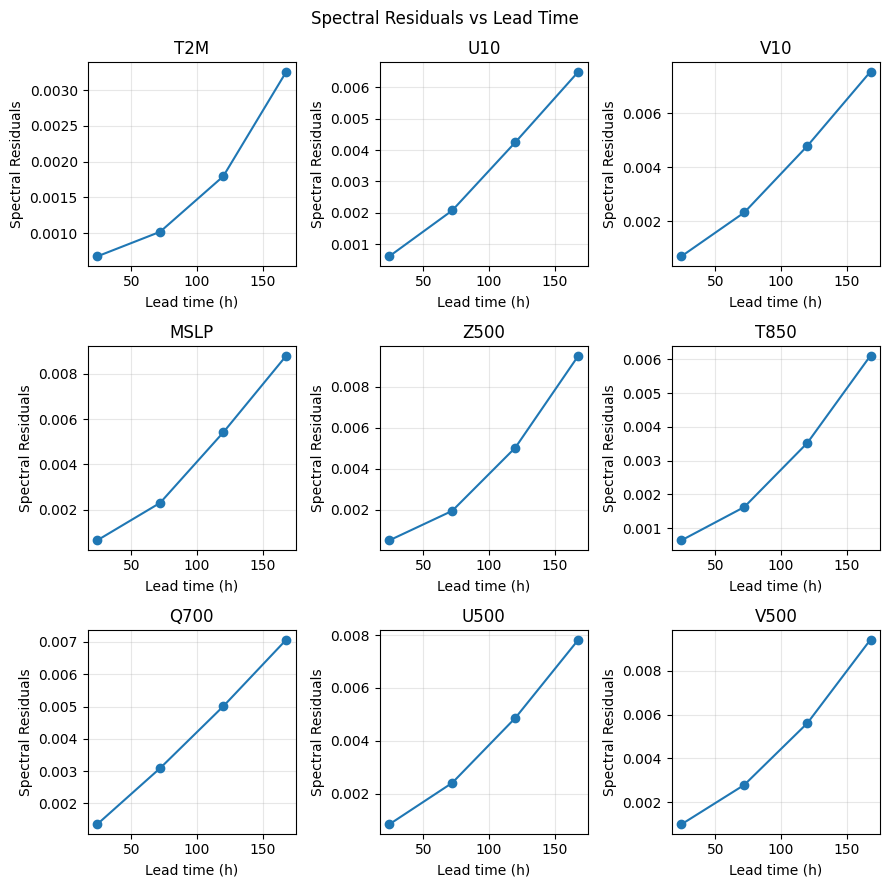

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9), sharey=False)
for ax, (label, var) in zip(axes.flat, key_vars.items()):
    div_per_lt = []
    for lt in lead_times:
        vals = [all_metrics[d][lt]["spec_res"][f"spec_res_{var}_{lt}"].item() for d in dates]
        div_per_lt.append(np.mean(vals))
    ax.plot(lead_times, div_per_lt, marker='o')
    ax.set_title(label)
    ax.set_xlabel("Lead time (h)")
    ax.set_ylabel("Spectral Residuals")
    ax.grid(True, alpha=0.3)
plt.suptitle("Spectral Residuals vs Lead Time")
plt.tight_layout()

In [48]:

key = "_w8A8"
patch = "_2"

all_metrics = torch.load(f"all_metrics{key}{patch}.pt", weights_only=False)
out_dir = f"plots{key}{patch}"
os.makedirs(out_dir, exist_ok=True)

results_dir = f"results{key}{patch}"
era5_test_dir = r'C:\Users\maxsh\era5_processed\test'
norm_dir = r'C:\Users\maxsh\Stormer\stormer\normalization_constants'

meta = torch.load(os.path.join(results_dir, "_meta.pt"), weights_only=False)
variables = meta["variables"]
var_to_ch = {v: i for i, v in enumerate(variables)}

normalize_mean = dict(np.load(os.path.join(norm_dir, "normalize_mean.npz")))
normalize_std = dict(np.load(os.path.join(norm_dir, "normalize_std.npz")))
mean_per_ch = np.concatenate([normalize_mean[v] for v in variables], axis=0)
std_per_ch = np.concatenate([normalize_std[v] for v in variables], axis=0)

def denorm(arr_norm, ch):
    return arr_norm * std_per_ch[ch] + mean_per_ch[ch]

def h5_index(dt, year_start=datetime.datetime(2020, 1, 1), data_freq=6):
    return int((dt - year_start).total_seconds() // 3600 // data_freq)

def load_ic(dt):
    idx = h5_index(dt)
    path = os.path.join(era5_test_dir, f"{dt.year}_{idx:04d}.h5")
    with h5py.File(path, "r") as f:
        return {v: f["input"][v][:] for v in key_vars.values()}

dates = list(all_metrics.keys())
lead_times = list(all_metrics[dates[0]].keys())
lt_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(lead_times)))

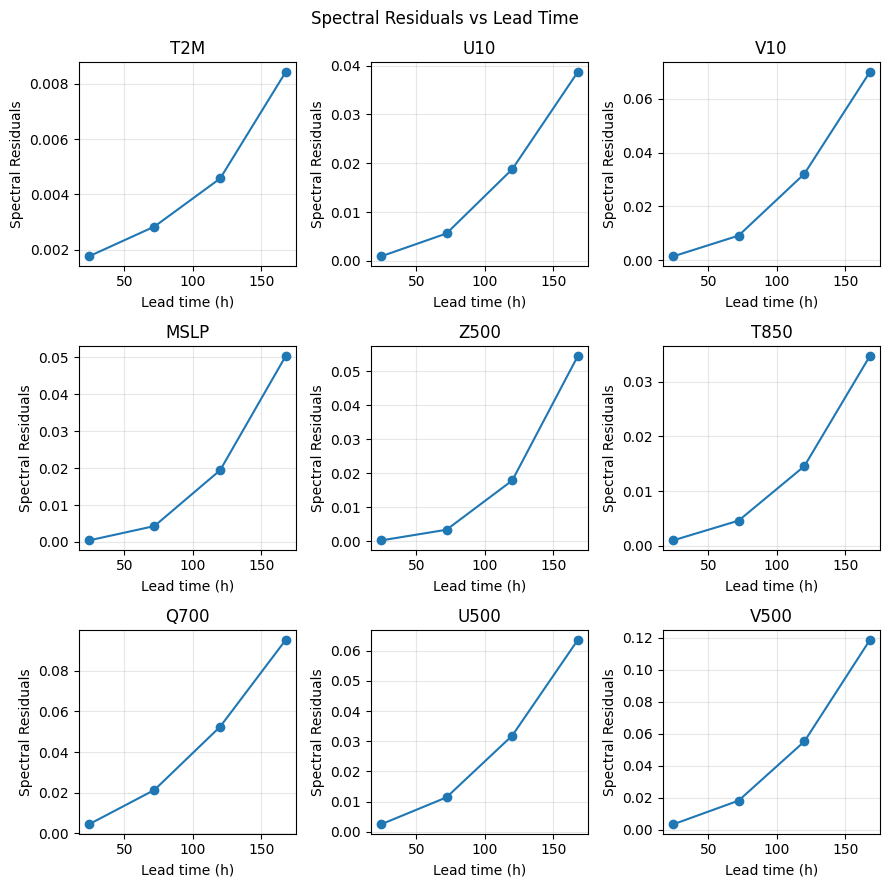

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9), sharey=False)
for ax, (label, var) in zip(axes.flat, key_vars.items()):
    div_per_lt = []
    for lt in lead_times:
        vals = [all_metrics[d][lt]["spec_res"][f"spec_res_{var}_{lt}"].item() for d in dates]
        div_per_lt.append(np.mean(vals))
    ax.plot(lead_times, div_per_lt, marker='o')
    ax.set_title(label)
    ax.set_xlabel("Lead time (h)")
    ax.set_ylabel("Spectral Residuals")
    ax.grid(True, alpha=0.3)
plt.suptitle("Spectral Residuals vs Lead Time")
plt.tight_layout()

## Effectuce Res

In [50]:
n_wave = all_metrics[dates[0]][lead_times[0]]["power spectrum"][f"wavenumbers_{list(key_vars.values())[0]}_{lead_times[0]}"].shape[0]
wavenum = all_metrics[dates[0]][lead_times[0]]["power spectrum"][f"wavenumbers_{list(key_vars.values())[0]}_{lead_times[0]}"].numpy()

psd_truth_sum = {lt: np.zeros((len(key_vars), n_wave)) for lt in lead_times}
psd_pred_sum = {lt: np.zeros((len(key_vars), n_wave)) for lt in lead_times}

for d in dates:
    for lt in lead_times:
        ps = all_metrics[d][lt]["power spectrum"]
        for i, var in enumerate(key_vars.values()):
            psd_truth_sum[lt][i] += ps[f"psd_truth_{var}_{lt}"].numpy()
            psd_pred_sum[lt][i] += ps[f"psd_preds_{var}_{lt}"].numpy()

n_d = len(dates)
psd_truth_mean = {lt: psd_truth_sum[lt] / n_d for lt in lead_times}
psd_pred_mean  = {lt: psd_pred_sum[lt]  / n_d for lt in lead_times}
# ratio of means: sum(PSD_pred) / sum(PSD_gt) — equivalent to mean(PSD_pred) / mean(PSD_gt)
ratio_mean = {lt: psd_pred_sum[lt] / psd_truth_sum[lt] for lt in lead_times}
wavelength_km = EARTH_CIRCUMFERENCE_KM / wavenum

In [40]:
ratios = ratio_mean[24][0]
ratios

array([1.00053894, 1.00593028, 1.01129639, 0.99701146, 0.99267411,
       1.00840861, 0.9977832 , 1.00353646, 1.00961453, 1.00343112,
       0.99271199, 1.02820102, 1.02532851, 1.0334427 , 1.00605977,
       1.03127651, 1.02345576, 1.05666119, 1.01851131, 1.0485872 ,
       1.03174989, 1.04439064, 1.04641881, 1.07148299, 1.08654657,
       1.08820633, 1.08731124, 1.09235526, 1.12075632, 1.11924504,
       1.10093426, 1.11995427, 1.1252774 , 1.12093334, 1.15444589,
       1.1546377 , 1.15961578, 1.16562867, 1.1964834 , 1.20010287,
       1.18252817, 1.19085746, 1.15624707, 1.22261414, 1.20210894,
       1.24345549, 1.22723698, 1.30208586, 1.27018864, 1.31033432,
       1.35865787, 1.29258001, 1.35109659, 1.35307875, 1.34217247,
       1.39833043, 1.33893144, 1.44828   , 1.41058854, 1.47619567,
       1.44784126, 1.52908034, 1.56086216, 1.57231551, 1.55715625,
       1.5933385 , 1.66981708, 1.64339642, 1.65589315, 1.65259044,
       1.64992265, 1.69236522, 1.698     , 1.80626498, 1.79113

In [26]:
np.argmax(ratios>1.2)


np.int64(39)

In [42]:
max_idx = np.argmax(ratios>1.2)
min_idx = np.argmax(ratios < 0.6) if np.any(ratios < 0.6) else np.argmax(ratios)
index = min(min_idx, max_idx)
index
wavelength_km[index]

np.float64(1001.875)

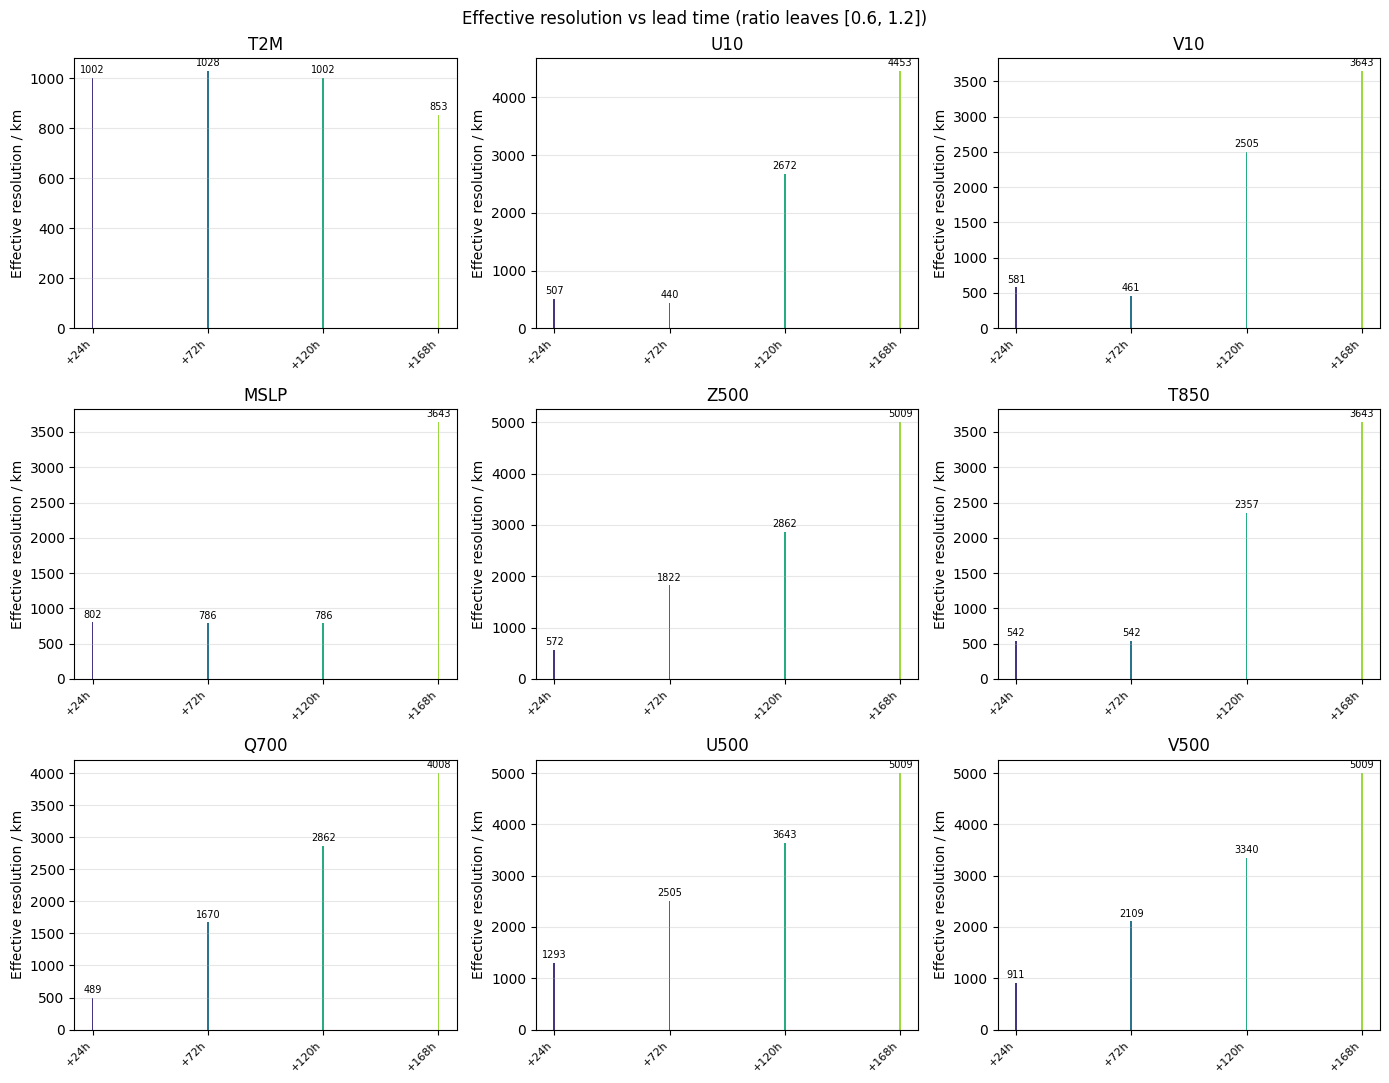

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for i, (label, var) in enumerate(key_vars.items()):
    ax = axes.flat[i]
    effective_res_by_lt = []
    for lt in lead_times:
        ratios = ratio_mean[lt][i]
        max_idx = np.argmax(ratios>1.2)
        min_idx = np.argmax(ratios < 0.6) if np.any(ratios < 0.6) else np.argmax(ratios)
        index = min(min_idx, max_idx)
        effective_res_by_lt.append(wavelength_km[index])
    bars = ax.bar(lead_times, effective_res_by_lt, color=lt_colors, width=0.7)
    ax.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
    ax.set_title(label)
    ax.set_xticks(lead_times)
    ax.set_xticklabels([f"+{lt}h" for lt in lead_times], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Effective resolution / km")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle(f"Effective resolution vs lead time "
             f"(ratio leaves [{0.6}, {1.2}])")
fig.tight_layout()
plt.show()
    
        

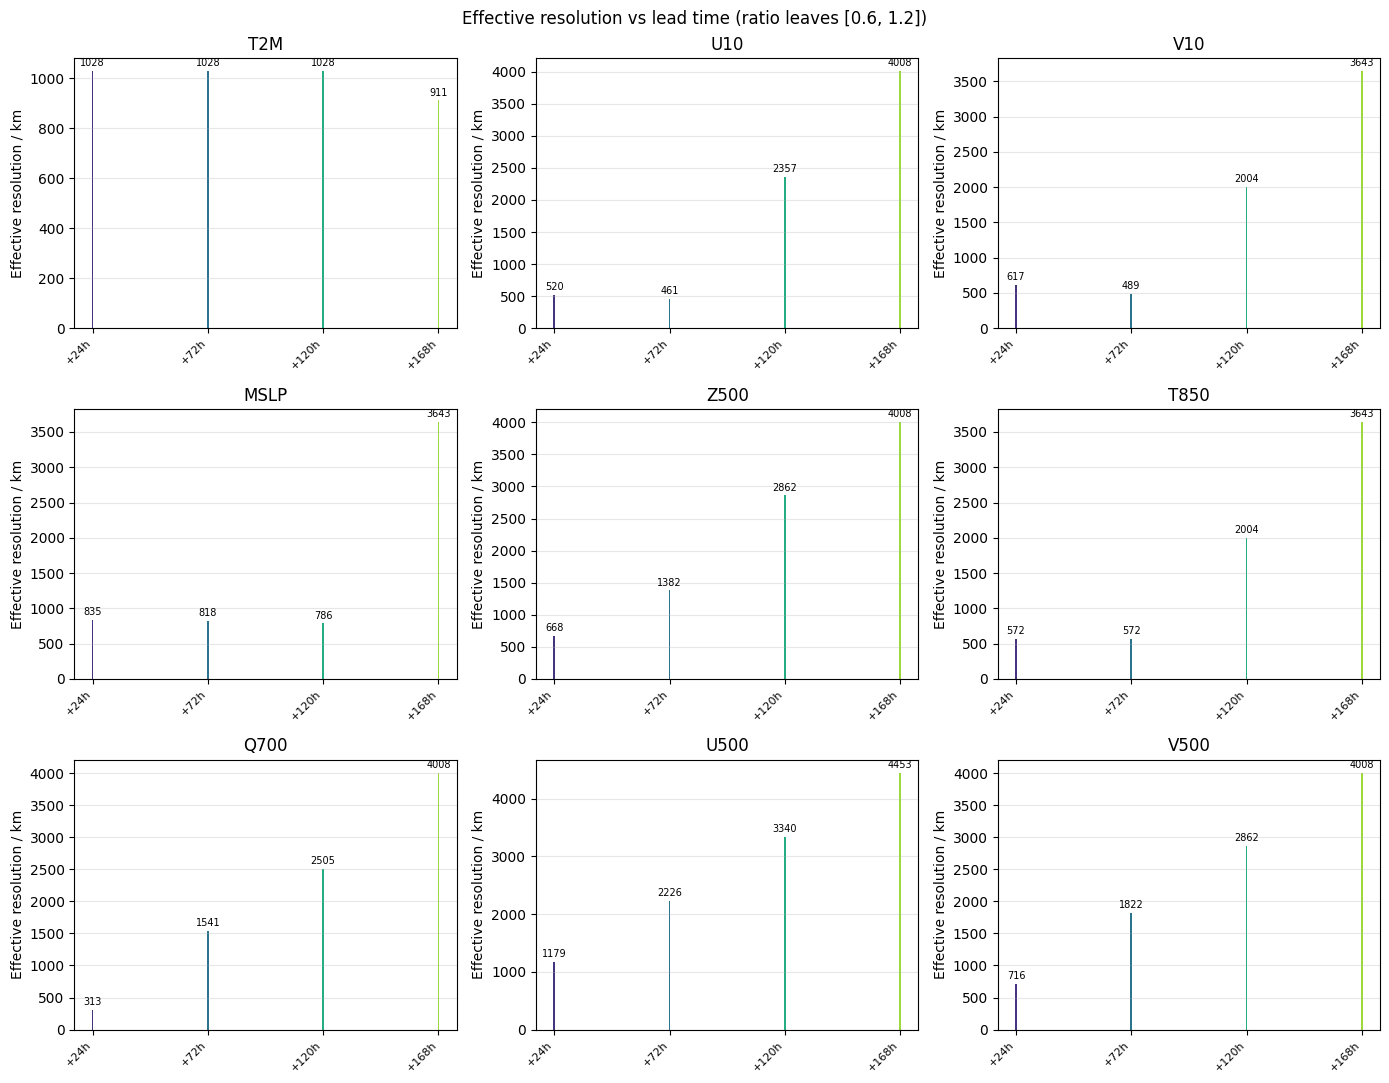

In [51]:

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for i, (label, var) in enumerate(key_vars.items()):
    ax = axes.flat[i]
    effective_res_by_lt = []
    for lt in lead_times:
        ratios = ratio_mean[lt][i]
        max_idx = np.argmax(ratios>1.2)
        min_idx = np.argmax(ratios < 0.6) if np.any(ratios < 0.6) else np.argmax(ratios)
        index = min(min_idx, max_idx)
        effective_res_by_lt.append(wavelength_km[index])
    bars = ax.bar(lead_times, effective_res_by_lt, color=lt_colors, width=0.7)
    ax.bar_label(bars, fmt="%.0f", fontsize=7, padding=2)
    ax.set_title(label)
    ax.set_xticks(lead_times)
    ax.set_xticklabels([f"+{lt}h" for lt in lead_times], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Effective resolution / km")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle(f"Effective resolution vs lead time "
             f"(ratio leaves [{0.6}, {1.2}])")
fig.tight_layout()
plt.show()
    
        

## Conservation

In [58]:
data = torch.load((os.path.join(results_dir, "20200101_12.pt")), map_location="cpu", weights_only=False)
preds = torch.from_numpy(data["results"].values()[0]['pred']).item()

TypeError: 'dict_values' object is not subscriptable

In [71]:
for lt, preds in data['results'].items():
    pred = torch.from_numpy(preds["pred"]).float() 
    y = torch.from_numpy(preds["gt"]).float()


In [76]:
preds

{'pred': array([[[[-1.422 , -1.423 , -1.428 , ..., -1.421 , -1.43  , -1.423 ],
          [-1.389 , -1.3955, -1.386 , ..., -1.386 , -1.374 , -1.389 ],
          [-1.383 , -1.399 , -1.3955, ..., -1.368 , -1.369 , -1.378 ],
          ...,
          [-1.282 , -1.279 , -1.287 , ..., -1.283 , -1.28  , -1.276 ],
          [-1.353 , -1.357 , -1.353 , ..., -1.347 , -1.353 , -1.3545],
          [-1.401 , -1.388 , -1.395 , ..., -1.386 , -1.397 , -1.383 ]],
 
         [[-0.2925, -0.4067, -0.2778, ..., -0.4814, -0.2942, -0.4004],
          [-0.4517, -0.583 , -0.4026, ..., -0.6426, -0.4639, -0.5986],
          [-0.2487, -0.346 , -0.2407, ..., -0.355 , -0.254 , -0.345 ],
          ...,
          [-1.513 , -1.503 , -1.433 , ..., -1.5205, -1.515 , -1.506 ],
          [-1.022 , -1.213 , -0.9824, ..., -1.285 , -1.057 , -1.24  ],
          [-0.9146, -0.957 , -0.8857, ..., -1.047 , -0.9775, -1.002 ]],
 
         [[-0.52  , -0.5537, -0.548 , ..., -0.465 , -0.4465, -0.5747],
          [-0.6626, -0.579 , -0.6

In [74]:
u = "u_component_of_wind_500"

In [75]:
u[:-3]

'u_component_of_wind_'